In [1]:
!pip install datasets huggingface_hub fsspec
!pip install  deepspeed transformers

In [2]:
# 檢查 cuda 版本
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


# DeepSpeed
- https://www.deepspeed.ai/getting-started/
- https://medium.com/@minh.hoque/how-to-train-large-language-models-9e0a56538e22

In [3]:
# 請根據您的 CUDA 版本選擇合適的指令
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu125
# 安裝 MPI (用於 DeepSpeed 通訊後端):
!apt-get update -y
!apt-get install -y libopenmpi-dev openmpi-bin
!pip install mpi4py
# 安裝 CUDA 編譯工具 (用於 DeepSpeed JIT 編譯自訂 CUDA 核心)
!apt-get install -y cuda-nvcc-12-5  # or correct version if needed

Looking in indexes: https://download.pytorch.org/whl/cu125
Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem 

## Generate the benchmark QA

In [4]:
from datasets import load_dataset
import random

def generate_qa_benchmark(random_seed:int=100, field:str="engineering_math", dataset:str="test"):
    qa_benchmark = []

    # Load the dataset
    ds = load_dataset('ikala/tmmluplus', field, split=dataset) # dataset : train/ val/ test

    # Get 30 random samples
    samples = random.sample(list(ds), random_seed)

    for i, s in enumerate(samples, 1):
        question_data = {
            "id": i,
            "question": s["question"],
            "options": {
                "A": s["A"],
                "B": s["B"],
                "C": s["C"],
                "D": s["D"]
            },
            "answer": s["answer"]
        }
        qa_benchmark.append(question_data)
    return  qa_benchmark

In [5]:
qa_benchmark = generate_qa_benchmark(random_seed=100, dataset="test")
qa_benchmark

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[{'id': 1,
  'question': '設 \\(\\bm{A},\\bm{B}\\) 都是四階非零矩陣，且 \\(\\bm{AB}=\\bm{O}\\)，則必有：',
  'options': {'A': '若 \\(r(\\bm{A})=4\\)，則 \\(r(\\bm{B})=1\\)',
   'B': '若 \\(r(\\bm{A})=1\\)，則 \\(r(\\bm{B})=3\\)；',
   'C': '若 \\(r(\\bm{A})=2\\)，則 \\(r(\\bm{B})=2\\)；',
   'D': '若 \\(r(\\bm{A})=3\\)，則 \\(r(\\bm{B})=1\\)；'},
  'answer': 'D'},
 {'id': 2,
  'question': '已知 \\( f(x) = x^4 - x^2 \\)， \\( x \\in [0,1] \\)，則\\( f(x) \\)在 \\([0，1]\\) 中最小值為何？',
  'options': {'A': '\\( -\\frac{1}{4} \\)',
   'B': '\\( -\\frac{1}{3} \\)',
   'C': '\\( -\\frac{1}{2} \\)',
   'D': '\\( -\\frac{1}{5} \\)'},
  'answer': 'A'},
 {'id': 3,
  'question': '求 \\( \\int_{0}^{\\pi} x^2 \\cos(x) dx = ? \\) 的積分',
  'options': {'A': '\\( \\frac{\\pi}{2} \\)',
   'B': '\\( \\frac{\\pi}{2} - 1 \\)',
   'C': '\\( 0 \\)',
   'D': '\\( \\pi - 1 \\)'},
  'answer': 'B'},
 {'id': 4,
  'question': '\\( A = \\begin{bmatrix} 3 & 1 \\\\ 2 & 4 \\end{bmatrix} \\)，其反矩陣 (Inverse matrix) 為 \\( B = \\begin{bmatrix} a & b \\\\ c & d \\en

## Startup the fine-tuning with deepspeed framework

In [6]:
import torch
import deepspeed
from transformers import AutoTokenizer, AutoModelForMaskedLM,BertForMaskedLM
from torch.utils.data import DataLoader, TensorDataset, random_split
from datasets import load_dataset
import argparse
import os
import math

## Access to your google drive

In [7]:
from google.colab import drive
drive.mount('/content/drive') # 用於儲存 training checkpoints

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup the argument for launch training

In [8]:
# add some arguments for training
parser = argparse.ArgumentParser(description="Training script.")
parser.add_argument("--cpu", action="store_true", help="If passed, will train on the CPU.")
parser.add_argument("--load_dir", action="store_true", help="The checkpoint saving path")
parser.add_argument("--ckpt_id", action="store_true", help="The checkpoint index")
parser.add_argument("--save_dir", type=str, default="./checkpoints")
# Jupyter/Colab 要傳入空參數避免解析 notebook 預設的系統參數
args = parser.parse_args(args=[])

In [9]:
# 創建儲存checkpoints 資料夾
GDRIVE_DIR = "/content/drive/MyDrive/deepspeed_checkpoints"
# 若資料夾不存在，自動建立
os.makedirs(GDRIVE_DIR, exist_ok=True)
# 更新 args.save_dir
args.save_dir = GDRIVE_DIR
# 創建儲存checkpoints 資料夾（使用本地路徑）
CHECKPOINT_DIR = os.path.join(os.path.dirname(os.path.abspath("./")), "checkpoints")
# 若資料夾不存在，自動建立
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# 更新 args.save_dir
args.save_dir = CHECKPOINT_DIR

## DeepSpeed config setup

In [ ]:
import random
import re
# 1. DeepSpeed Configuration (Replace with your actual ds_config.json or parameters)
config_params = {
    "train_batch_size": 32,
    "gradient_accumulation_steps": 1,
    "optimizer": {
        "type": "Adam",
        "params": {
            "lr": 1e-4,
            "betas": [0.9, 0.999],
            "eps": 1e-9,
            "weight_decay": 3e-7
        }
    },
    "scheduler": {
        "type": "WarmupLR",
        "params": {
            "warmup_min_lr": 0,
            "warmup_max_lr": 1e-5,
            "warmup_num_steps": 100
        }
    },
    "fp16": {
        "enabled": False # Or False, if not using mixed precision (跟 colab T5 gpus 有關，有時 gradient scaling 沒設好，導致梯度很小 → 更新幅度幾乎 0)
    },
    "zero_optimization": {
        "stage": 0 # Or 1, 2, 3 depending on your ZeRO optimization level
    }
}

# --- Data Preparation (Replace with your actual data loading and preprocessing) ---
def get_dataset(tokenizer, num_samples=100, max_length=50, test_ratio=0.05,val_ratio=0.25, seed=42):
    input_text= []
    task_list = [
                'traditional_chinese_medicine_clinical_medicine', 'clinical_psychology', 'technical', 'culinary_skills', 'mechanical', 'logic_reasoning', 'real_estate',
                'general_principles_of_law', 'finance_banking', 'anti_money_laundering', 'ttqav2', 'marketing_management', 'business_management', 'organic_chemistry', 'advance_chemistry',
                'physics', 'secondary_physics', 'human_behavior', 'national_protection', 'jce_humanities', 'politic_science', 'agriculture', 'official_document_management',
                'financial_analysis', 'pharmacy', 'educational_psychology', 'statistics_and_machine_learning', 'management_accounting', 'introduction_to_law', 'computer_science', 'veterinary_pathology',
                'accounting', 'fire_science', 'optometry', 'insurance_studies', 'pharmacology', 'taxation', 'trust_practice', 'geography_of_taiwan', 'physical_education', 'auditing', 'administrative_law',
                'education_(profession_level)', 'economics', 'veterinary_pharmacology', 'nautical_science', 'occupational_therapy_for_psychological_disorders',
                'basic_medical_science', 'macroeconomics', 'trade', 'chinese_language_and_literature', 'tve_design', 'junior_science_exam', 'junior_math_exam', 'junior_chinese_exam',
                'junior_social_studies', 'tve_mathematics', 'tve_chinese_language', 'tve_natural_sciences', 'junior_chemistry', 'music', 'education', 'three_principles_of_people',
                'taiwanese_hokkien'
                ]
    for id, task in enumerate(task_list):
        task_data = load_dataset('ikala/tmmluplus', task)['train']
        if id == 0:
            # 第一次建立 key 為欄位名稱
            features = [col.strip() for col in task_data.column_names]
        context = [task_data[col] for col in task_data.column_names]
        transposed = list(zip(*context))
        for row in transposed:
            question_dict = {key: value for key, value in zip(features, row)}
            # formatted_qa.append(question_dict)
            input_text.append("".join(f"{key}:{question_dict[key]}\n" for key in features))

    n = len(input_text)
    # 切分 5% 測試集資料
    rng = random.Random(seed)
    all_idx = list(range(n))
    rng.shuffle(all_idx)   # 隨機打亂

    n_test = max(1, math.floor(n * test_ratio))   # 至少 1 筆，避免空測試集
    n_val  = max(1, math.floor(n * val_ratio))
    n_train = n - n_test - n_val

    train_idx, val_idx, test_idx = all_idx[:n_train], all_idx[n_train:n_train+n_val], all_idx[n_train+n_val:]

    train_text = [input_text[i] for i in range(n) if i in train_idx]
    val_text   = [input_text[i] for i in range(n) if i in val_idx]
    test_text  = [input_text[i] for i in range(n) if i in test_idx]
    print("資料數量：", len(train_text), len(val_text), len(test_text))
    print(f"訓練資料:{train_text}")

    def make_dataset(texts:list):
        """
        texts(list[str]): data from train or val or test
        """
        # Tokenize all texts (input_texts is list)
        enc = tokenizer(texts, return_tensors="pt", padding="max_length",
                        truncation=True, max_length=max_length)
        # Create labels (for language modeling, labels are typically the input_ids shifted)
        labels = enc.input_ids.clone()
        labels[labels == tokenizer.pad_token_id] = -100
        return TensorDataset(enc.input_ids, enc.attention_mask, labels)
    return make_dataset(train_text), make_dataset(val_text), test_text

## Load Model and Tokenizer

In [11]:
from transformers import AutoTokenizer, AutoModelForMultipleChoice

model_name = 'bert-base-chinese' # You can choose other GPT-2 variants like 'gpt2-medium'
# tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Add a padding token if it doesn't exist (GPT-2 usually doesn't have one by default)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
# model = GPT2LMHeadModel.from_pretrained(model_name)
# model.resize_token_embeddings(len(tokenizer)) # Resize embeddings if new tokens were added (special_tokens)
print("Mask token:", tokenizer.mask_token)
print("Mask token id:", tokenizer.mask_token_id)

model = AutoModelForMaskedLM.from_pretrained(model_name) # Masked Language Modeling (MLM) 的預設 loss（即 outputs.loss）設計的，也就是模型學習「填空」

Mask token: [MASK]
Mask token id: 103


Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [12]:
tokenizer

BertTokenizerFast(name_or_path='bert-base-chinese', vocab_size=21128, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

## Prepare Dataset

In [15]:
# Spit data into train / val / test
train_data, val_data, test_data = get_dataset(tokenizer)
# Build up the train / val / test dataloader
train_loader = DataLoader(train_data, batch_size=config_params["train_batch_size"], shuffle=True)
val_loader = DataLoader(val_data, batch_size=config_params["train_batch_size"], shuffle=False)

資料數量： 82 28 5
訓練資料:['question:多處骨折患者，發熱、無汗、脈洪大而虛，重按全無，依《醫宗金鑑．正骨心法要旨》之分類，此乃：\nA:血脫\nB:血瘀發熱\nC:感染\nD:血虛發熱\nanswer:D\n', 'question:依《醫宗金鑑．金匱要略．嘔吐噦下痢》原文，有關「下痢」的敘述，下列何者錯誤？\nA:下痢腹脹滿，身體疼痛者，先溫其裡，乃攻其表\nB:下痢，三部脈皆平，按之心下堅者，急下之\nC:下痢氣者，當清其氣\nD:下痢清穀，不可攻其表\nanswer:C\n', 'question:依《金匱要略》對消渴的治療，下列何者錯誤？\nA:脈浮，小便不利，微熱消渴者，宜利小便，發汗，五苓散主之\nB:脈浮發熱，渴欲飲水，小便不利者，豬苓湯主之\nC:男子消渴，小便反多，以飲一斗，小便一斗，腎氣丸主之\nD:渴欲飲水，口乾舌燥者，五苓散主之\nanswer:D\n', 'question:ADHD兒童隨時間增長或是疲憊時，保持持續專注力的能力有困難，下列何者是此項能力缺陷？\nA:選擇性注意力（selective attention）\nB:警戒度（alerting）\nC:注意力的容量（attentional capacity）\nD:警覺度（vigilance）\nanswer:D\n', 'question:下列何物質最不可能對於失智症認知功能症狀有效？\nA:重酒石酸卡巴拉汀（rivastigmine）\nB:多奈哌齊（donepezil）\nC:苯二氯平類（benzodiazepines）\nD:加蘭他敏（galantamine）\nanswer:C\n', 'question:關於人本主義中的自我實現（self-actualizing）概念，下列敘述何者錯誤？\nA:壓力與挫折經驗會讓「現實我」與「真實我」更接近\nB:所有人皆可達到功能發展的最高潛能\nC:心理病理的產生，與自我實現過程中的困難障礙有關\nD:人性基本上是良善的\nanswer:A\n', 'question:依據高情緒表露的觀點，下列何者是家族治療運用在思覺失調症的主要目標？\nA:減少藥物的使用\nB:減少患者的不適當行為\nC:協助家屬建立患者獨立生活的能力\nD:改善家中的溝通技巧\nanswer:D\n', 'question:小強就讀小學二

## Output test data into JSON format
Generate the test_qa_data.json to validate the performance of fine-tuning LLM

In [ ]:
import re
import json

result = []
for item in test_data:
    # 擷取題目與選項
    q_match = re.search(r"question:(.*?)answer:", item, re.S)
    # 擷取正確答案代號
    ans_match = re.search(r"answer:([A-D])", item)

    if not q_match or not ans_match:
        continue

    question_block = q_match.group(1).strip()
    correct_label = ans_match.group(1).strip()

    # 找出對應文字內容
    option_match = re.search(rf"{correct_label}:(.*?)\n", item)
    correct_answer = option_match.group(1).strip() if option_match else ""

    result.append({
        "question": question_block,
        "answer": correct_answer
    })

# 輸出成 JSON
with open("./test_qa_data.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=4)

print("✅ 已輸出 test_qa_data.json")

## Initialize DeepSpeed Engine

In [16]:
# Make sure deepspeed is installed and ds_config.json is configured or use config_params
try:
  model_engine, optimizer, _, scheduler = deepspeed.initialize(
      model=model,
      model_parameters=model.parameters(),
      config_params=config_params # or use `config="path/to/ds_config.json"`
  )
  print(f"Using DeepSpeed ZeRO Stage: {model_engine.zero_optimization_stage()}")
  print(f"FP16 enabled: {model_engine.fp16_enabled()}")

except Exception as e:
  print(f"⚠️ DeepSpeed 初始化失敗: {e}")
  print("嘗試使用標準 PyTorch 訓練...")
  # 如果 DeepSpeed 初始化失敗，使用標準 PyTorch 優化器
  import torch.optim as optim
  # 設置設備
  device = torch.device("cuda" if torch.cuda.is_available() and not args.cpu else "cpu")
  model.to(device)
  optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999), eps=1e-9, weight_decay=3e-7)
  from torch.optim.lr_scheduler import LambdaLR
  scheduler = LambdaLR(optimizer, lr_lambda=lambda step: min(1.0, step / 100) * (1e-5 / 1e-4))
  model_engine = model
  print(f"使用標準 PyTorch 訓練，設備: {device}")


[2025-12-09 15:09:33,351] [WARNING] [lr_schedules.py:690:get_lr] Attempting to get learning rate from scheduler before it has started
Using DeepSpeed ZeRO Stage: 0
FP16 enabled: False


## Training loop wit input data (QA corpus)
此訓練模型主要是出現在 自回歸模型（Causal LM）或 Masked LM 的 loss 計算裡，
在 語言模型訓練中，模型的目標是為給定前面的 token，預測下一個 token
`texts` 的內容像是：
```
"法國的首都是哪裡？ 巴黎"
```
labels = input_ids.clone() 表示你要訓練模型「預測出這整句話的每一個 token」
如果 input 是
```
[CLS] 法 國 的 首 都 是 哪 裡 ？ 巴 黎 [SEP]
```
訓練過程中，模型會透過
```python
loss = CrossEntropyLoss(logits, labels_shifted)
```
此訓練方式的問題
- ❌ 模型其實是在做自動補完
- ⚠️ loss 的收斂不代表它會選對答案

In [18]:
num_epochs = 30 # Example number of epochs
save_interval =  10

#load checkpoint
if args.load_dir and args.ckpt_id:
  try:
      if hasattr(model_engine, 'load_checkpoint'):
          _, client_sd = model_engine.load_checkpoint(args.load_dir, args.ckpt_id)
          step = client_sd.get('step', 0)
          print(f"✅ 已載入檢查點: {args.load_dir}/{args.ckpt_id}")
      else:
          print("⚠️ 當前模式不支持載入檢查點")
  except Exception as e:
      print(f"⚠️ 載入檢查點失敗: {e}")


# spit dataser with train / validattion / test
loss_history = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model_engine.train()
    total_loss = 0 # initailize the loss
    for step, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = batch
        # transfer the calculations in
        input_ids = input_ids.to(model_engine.local_rank)
        labels = labels.to(model_engine.local_rank)
        attention_mask = attention_mask.to(model_engine.local_rank)

        outputs = model_engine(input_ids=input_ids,attention_mask=attention_mask, labels=labels)
        # loss calculations
        t_loss = outputs.loss
        # back prop
        if hasattr(model_engine, 'backward'):
            # DeepSpeed 模式
            model_engine.backward(t_loss)
            model_engine.step() # Includes optimizer.step() and scheduler.step()
        else:
            # 標準 PyTorch 模式
            optimizer.zero_grad()
            t_loss.backward()
            optimizer.step()
            scheduler.step()
        total_loss += t_loss.item()
        if step % save_interval == 0: # Print loss every 10 steps
          print(f"Step {step}/{len(train_loader)}, Loss: {t_loss.item()}")
    avg_train_loss = total_loss / len(train_loader)
    print(f"Average Training Loss: {avg_train_loss:.4f}")

    # --- Evaluation (Optional, add your evaluation logic here) ---
    model_engine.eval()
    val_loss = 0
    with torch.no_grad():
        for val_step, batch in enumerate(val_loader):
            input_ids, attention_mask, labels = batch
            input_ids = input_ids.to(model_engine.local_rank)
            labels = labels.to(model_engine.local_rank)
            attention_mask = attention_mask.to(model_engine.local_rank)

            outputs = model_engine(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            v_loss = outputs.loss.item()
            val_loss += v_loss
            # 只在每個 epoch 結束時記錄一次驗證損失
            if val_step == len(val_loader) - 1:
                loss_history.append(val_loss / len(val_loader))
            # save checkpoint
            if val_step % save_interval:
              # 5. Saving Checkpoints (DeepSpeed handles this internally based on config, but you can also save manually)
              # 定義 client_state，儲存你想要的訓練資訊
              client_state = {
                  "step": val_step,
                  "val_loss": val_loss
              }
              ckpt_id = f"step{val_step}"
              # model_engine.save_checkpoint(
              #     save_dir=args.save_dir,
              #     tag=ckpt_id,
              #     client_state=client_state
              # )
              # print(f"✅ Checkpoint saved at {ckpt_id}")
              #model_engine.save_checkpoint(args.save_dir) # This creates a directory
    avg_val_loss = val_loss / len(val_loader)
    print(f"Average Validation Loss: {avg_val_loss:.4f}")

Epoch 1/40
Step 0/3, Loss: 0.7697569131851196
Average Training Loss: 0.7475
Average Validation Loss: 0.7358
Epoch 2/40
Step 0/3, Loss: 0.7271091938018799
Average Training Loss: 0.7029
Average Validation Loss: 0.6334
Epoch 3/40
Step 0/3, Loss: 0.6449610590934753
Average Training Loss: 0.6275
Average Validation Loss: 0.5872
Epoch 4/40
Step 0/3, Loss: 0.5987423658370972
Average Training Loss: 0.5742
Average Validation Loss: 0.5376
Epoch 5/40
Step 0/3, Loss: 0.5284181833267212
Average Training Loss: 0.5184
Average Validation Loss: 0.4918
Epoch 6/40
Step 0/3, Loss: 0.5051319599151611
Average Training Loss: 0.4825
Average Validation Loss: 0.4499
Epoch 7/40
Step 0/3, Loss: 0.450822114944458
Average Training Loss: 0.4359
Average Validation Loss: 0.4079
Epoch 8/40
Step 0/3, Loss: 0.4080550968647003
Average Training Loss: 0.3926
Average Validation Loss: 0.3621
Epoch 9/40
Step 0/3, Loss: 0.3661010265350342
Average Training Loss: 0.3469
Average Validation Loss: 0.3054
Epoch 10/40
Step 0/3, Loss: 0

In [19]:
import matplotlib.pyplot as plt

def plot_loss_curve(loss_history):
  plt.figure(figsize=(10, 4))
  plt.plot(loss_history, label='Validation Loss')
  plt.xlabel("Step")
  plt.ylabel("Loss")
  plt.title("Validation Loss Curve")
  plt.legend()
  plt.grid(True)
  plt.show()

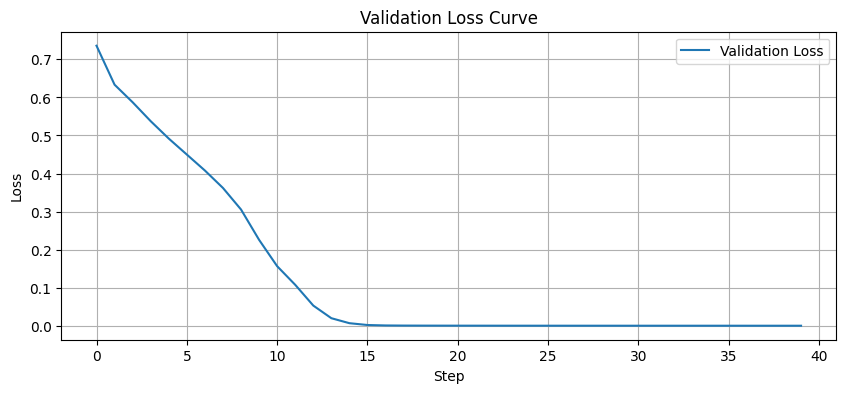

In [20]:
plot_loss_curve(loss_history)

##  (Zero Redundancy Optimizer) ZeRO
It is a powerful set of memory optimization techniques that enable effective training of large models with trillions of parameters, such as GPT-2 and Turing-NLG 17B.

是 DeepSpeed 提供的訓練優化的核心，它是一套减少分布式模型训练所需内存量的技術。
數據並行(Data Parallelism)策略會將模型複製到多 gpu 設備中，但顯然會造成不必要的資源冗餘
deepSpeed 設置了三種 stage:\n
- Stage 0：不採用任何内存優化方案，也就是普通 DDP
- Stage 1：Optimizer State Partitioning
- Stage 2：Gradient Partitioning
- Stage 3：Parameter Partitioning





In [21]:
# To save the final model for Hugging Face Transformers compatibility:
save_directory = "./my_bert_finetuned_model_hf" # Define the save directory

if hasattr(model_engine, 'zero_optimization_stage') and model_engine.zero_optimization_stage() == 3:
    # If using ZeRO Stage 3, need to consolidate weights first on rank 0
    if hasattr(model_engine, 'global_rank') and model_engine.global_rank == 0:
        # model_engine.module is the original Hugging Face model
        model_engine.module.save_pretrained(save_directory)
        tokenizer.save_pretrained(save_directory)
        print(f"Model and tokenizer saved to {save_directory} (ZeRO Stage 3 consolidated from rank 0)")

# rank : 反映了矩陣所能表示的線性獨立
elif hasattr(model_engine, 'global_rank') and model_engine.global_rank == 0:
    # For ZeRO stages 0, 1, 2 or no ZeRO, save from rank 0
    model_engine.module.save_pretrained(save_directory)
    tokenizer.save_pretrained(save_directory)
    print(f"Model and tokenizer saved by rank 0 to {save_directory} (ZeRO Stage < 3 or no ZeRO)")

elif not hasattr(model_engine, 'global_rank'):
    # Fallback for truly non-distributed single-process execution not managed by deepspeed launcher (less common for DeepSpeed)
    # Or if DeepSpeed is not used at all (though the script is a DeepSpeed script)
    model_engine.module.save_pretrained(save_directory)
    tokenizer.save_pretrained(save_directory)
    print(f"Model and tokenizer saved to {save_directory} (Likely non-distributed or DeepSpeed not fully initialized for distributed info)")

print(f"Training complete. Fine-tuned model and tokenizer attempted to be saved. Check logs above for status and path: {save_directory}.")


Model and tokenizer saved by rank 0 to ./my_bert_finetuned_model_hf (ZeRO Stage < 3 or no ZeRO)
Training complete. Fine-tuned model and tokenizer attempted to be saved. Check logs above for status and path: ./my_bert_finetuned_model_hf.


## Chat with fine-tuning model




In [37]:
def chat_with_tuning_llm(prompt, top_k=200):
    """
    Args:
        prompt (str): 輸入文字內容
        top_k (int):

    Returns:
        list: _description_
    """
    try:
        # 使用與保存時相同的路徑邏輯
        model_path = "./content/drive/MyDrive/my_bert_finetuned_model_hf_format"
        print(f"Loading tokenizer from {model_path}")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModelForMaskedLM.from_pretrained(model_path).to(device)
        model.eval()
    except Exception as e:
        print(f"Error loading tokenizer: {e}")
        return
    # prompt 加入 [MASK]，BERT (MLM 模式，必須加入 [MASK])
    # 而 GPT (CLM 模式，不需要 [MASK])
    if tokenizer.mask_token not in prompt:
        prompt = prompt + tokenizer.mask_token
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    mask_token_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    mask_token_logits = logits[0, mask_token_index, :]
    top_k_ids = torch.topk(mask_token_logits, top_k, dim=1).indices[0].tolist()
    predicted_tokens = [tokenizer.decode([idx]).strip() for idx in top_k_ids]
    return predicted_tokens

## Chat with LLM without tuning

In [23]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForCausalLM
import torch

def general_chat(prompt, top_k=200):
    accuracy = []
    device = torch.device("cuda")
    print(f"Using device: {device}")
    try:
        tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
        model = AutoModelForMaskedLM.from_pretrained("bert-base-chinese")
        model.to(device)
        model.eval()  # Set the model to evaluation mode
    except Exception as e:
        print(f"Error loading tokenizer: {e}")
        return
    print("\\nModel and tokenizer loaded successfully.\\n")
    print("\nModel and tokenizer loaded successfully.\n")
    # --- Interact with the LLM---
    # BERT 模型不適合用於文本生成，這裡僅作示例
    # 實際使用時應該使用 GPT 類模型
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        # BERT 不適合直接生成，這裡僅作示例
        # 實際應該使用 GPT 類模型進行生成
        output = model(input_ids=input_ids)
        # 簡單返回輸入（因為 BERT 不是生成模型）
        resp = tokenizer.decode(input_ids[0], skip_special_tokens=True)
    return resp

## LLM with evaluation

In [43]:
EVAL_PROMPT = """
[Question]: {question}
[Reference Answer]: {gold_answer}
[Model A Answer]: {baseline_output}
[Model B Answer]: {finetuned_output}

Act as an impartial judge.
Evaluate both Model A and Model B’s answers with respect to correctness, relevance, and completeness.
Must give a score from 1-10 for each, and declare which is better:
<your evaluation here>
"""

class EvalLLm:
    def __init__(self,
            model_a_resp=None,
            model_b_resp=None,
            ground_truth=None,
            prompt:str=None,
            model_name:str="Qwen/Qwen2.5-3B-Instruct",
            device:str=None):
        self.model = model_name
        self.tokenizer =  AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        if device:
            self.device = torch.device(device)
        else:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model_a_resp = model_a_resp
        self.model_b_resp = model_b_resp
        self.ground_truth = ground_truth
        self.prompt = prompt

    def evaluation(self, question:str):
        """
        對 prompt 進行評估，回傳模型輸出
        """
        # 構建評估 prompt
        if self.ground_truth:
            # 有標準答案時，使用完整的評估 prompt
            eval_prompt = EVAL_PROMPT.format(
                question=question,
                gold_answer=self.ground_truth,
                baseline_output=str(self.model_a_resp) if self.model_a_resp else "N/A",
                finetuned_output=str(self.model_b_resp) if self.model_b_resp else "N/A"
            )
        else:
            # 沒有標準答案時，使用簡化 prompt
            eval_prompt = f"""
            [Question]: {question}
            [Model A Answer]: {str(self.model_a_resp) if self.model_a_resp else "N/A"}
            [Model B Answer]: {str(self.model_b_resp) if self.model_b_resp else "N/A"}

            Act as an impartial judge.
            Evaluate both Model A and Model B's answers with respect to correctness, relevance, and completeness.
            Give a score from 1-10 for each, and declare which is better.
            Format your response as: "Model A: X/10, Model B: Y/10, Better: [A/B]"
            """
            # 構建對話消息
        messages = [
            {"role": "system", "content": "You are an impartial judge evaluating model answers."},
            {"role": "user", "content": eval_prompt}
        ]

        # 應用聊天模板
        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        # 編碼輸入
        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

        # 生成評估結果
        with torch.no_grad():
            generated_ids = self.model.generate(
                **model_inputs,
                max_new_tokens=512,
                temperature=0.7,
                do_sample=True
            )

        # 提取生成的文本（去除輸入部分）
        generated_ids = [
            output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]

        # 解碼回答
        response = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        print("模型回答：\n", response)

        # 嘗試從回答中提取分數（支持多種格式）
        scores = []
        all_scores = re.findall(r'(?:Score|分數)[:\s]*(\d+)(?:/10)?', response, re.IGNORECASE)

        # 優先使用標準格式
        # if len(found_scores1) >= 2:
        #     scores = [int(s) for s in found_scores1[:2]]
        #     print(f"✅ 使用標準格式解析分數: Model A = {scores[0]}/10, Model B = {scores[1]}/10")
        # # 其次使用 Model A/B 部分的分數
        # elif len(scores_a) > 0 and len(scores_b) > 0:
        #     scores = [scores_a[0], scores_b[0]]
        #     print(f"✅ 使用 Model A/B 部分解析分數: Model A = {scores[0]}/10, Model B = {scores[1]}/10")
        # 最後嘗試按順序提取所有分數
        if len(all_scores) >= 2:
            scores = [int(s) for s in all_scores[:2]]
            print(f"✅ 使用順序解析分數: Model A = {scores[0]}/10, Model B = {scores[1]}/10")
        # 如果只有一個分數，嘗試推斷
        elif len(all_scores) == 1:
            # 檢查文本中是否有明確的 Model A/B 標記
            if 'Model A' in response[:len(response)//2] and 'Model B' in response[len(response)//2:]:
                # 假設第一個分數是 Model A，但需要更多信息
                print(f"⚠️ 只找到一個分數: {all_scores[0]}，無法確定 Model A/B 的對應關係")
            else:
                print(f"⚠️ 只找到一個分數: {all_scores[0]}，無法解析兩個模型的分數")
        else:
            # 如果無法解析，返回空列表
            print("⚠️ 無法從回答中解析分數，請手動查看評估結果")
            print("💡 提示：Qwen 的回答格式可能不符合預期，但評估內容仍然有效")
        return scores

    def judgement(self, scores:list, full_score:int=10):
        """
        根據分數列表計算準確率
        """
        if not scores:
            print("⚠️ scores 為空，無法計算統計信息")
            print("💡 這可能是因為 Qwen 的評估格式無法自動解析，但評估內容仍然有效")
            return {"accuracy": 0.0, "avg_score": 0.0, "total_evaluations": 0}
        # 如果 scores 是單個問題的兩個分數 [model_a, model_b]
        if len(scores) == 2 and all(isinstance(s, (int, float)) and 0 <= s <= full_score for s in scores):
            model_a_score, model_b_score = int(scores[0]), int(scores[1])
            avg_score = (model_a_score + model_b_score) / 2
            better_model = "B" if model_b_score > model_a_score else "A" if model_a_score > model_b_score else "Tie"
            print(f"📊 評估結果:")
            print(f"   Model A: {model_a_score}/{full_score}")
            print(f"   Model B: {model_b_score}/{full_score}")
            print(f"   平均分數: {avg_score:.2f}/{full_score}")
            print(f"   更好的模型: Model {better_model}")
            return {
                "model_a_score": model_a_score,
                "model_b_score": model_b_score,
                "avg_score": avg_score,
                "better_model": better_model,
                "total_evaluations": 1
            }
        # 如果 scores 是多個問題的分數列表（批量評估）
        else:
            total = len(scores)
            correct = sum(1 for s in scores if s == full_score)
            accuracy = correct / total * 100 if total > 0 else 0.0
            avg_score = sum(scores) / total if total > 0 else 0.0
            print(f"📊 批量評估結果:")
            print(f"   總評估數: {total}")
            print(f"   準確率 (滿分): {accuracy:.2f}% ({correct}/{total})")
            print(f"   平均分數: {avg_score:.2f}/{full_score}")
            return {
                "accuracy": accuracy,
                "avg_score": avg_score,
                "total_evaluations": total,
                "correct_count": correct
            }




In [25]:
import re
def extract_qa_pair(text):
   # 提取 question 部分（含選項）
  q_part = re.search(r"question:(.*?)(?=answer:)", text, re.S).group(1).strip()
  # 提取 answer
  a_part = re.search(r"answer:(.*)", text).group(1).strip()
  print("## Question：")
  print(q_part)
  print("="*100)
  print("\n## Answer：")
  print(a_part)
  return q_part, a_part

In [26]:
def exe_chat(test_qa, max_length=10):
    # parallel with multi-workers
    for qa in test_qa:
      # 如果 test_qa 是字符串列表，使用 extract_qa_pair
      if isinstance(qa, str):
          q_part, a_part = extract_qa_pair(qa)
      # 如果 test_qa 是字典列表，直接使用
      elif isinstance(qa, dict):
          q_part = qa.get('question', '')
          a_part = qa.get('answer', '')
      else:
          print(f"⚠️ 不支持的數據格式: {type(qa)}")
          continue

      q_part = q_part + "[MASK]"
      tuning_result = chat_with_tuning_llm(q_part, top_k=200)
      print("Tuning LLM Generated text:", tuning_result)
      original_result = general_chat(q_part)
      print("Generated text:", original_result)
      eval_llm = EvalLLm(tuning_result, original_result, a_part, q_part)
      scores = eval_llm.evaluation(q_part)
      eval_llm.judgement(scores)



In [1]:
exe_chat(test_data)

NameError: name 'exe_chat' is not defined

## **Reference**
- https://zhuanlan.zhihu.com/p/690690979
- https://www.deepspeed.ai/tutorials/zero/
- https://blog.csdn.net/RandyHan/article/details/132630214
- https://www.kaggle.com/code/afrozs/fine-tuned-gpt2-llm
- https://medium.com/@eraparihar98/understanding-masked-language-modeling-as-a-pretraining-task-4a887ec61c8d
- https://github.com/ayoolaolafenwa/TrainNLP